In [1]:
import pandas as pd 
import sys
sys.path.append('../../code')
import plot_of_experiment_data 
import matplotlib.pyplot as plt
import matplotlib
import warnings
import numpy as np 
warnings.filterwarnings("ignore", message="findfont: Font family 'Arial' not found.")
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [2]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

def pval_to_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


In [3]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project/figure/figure3_olfactory_pathway/data/kir2.1_projection_neurons.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
sheets = ['WT','Or56a>Kir2.1','R85E04>Kir2.1']
data_df_figG = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_figG[s] = df
mean_df_figG = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
std_df_figG = pd.DataFrame(index=sheets,columns=['sugar','sugar+geosmin'])
for i,df in data_df_figG.items():
    mean_df_figG.loc[i] = df.mean()
    std_df_figG.loc[i] = std_err(df.values)
    

/home/se/anaconda3/envs/flywire/lib/python3.9/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' n

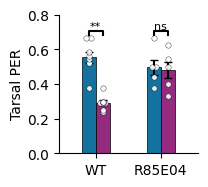

In [4]:
fig,ax = plt.subplots(1,1,figsize=(1.8,1.8))

ax,stat_all = plot_of_experiment_data.draw_paired_bar_figure(
    data=data_df_figG,
    mean_df=mean_df_figG,
    err_df=std_df_figG,
    ax=ax,
    conds=['WT', 'R85E04>Kir2.1'],
    groups=['sugar', 'sugar+geosmin'],
    get_values=lambda data, cond, group: data[cond][group],
    stat_pairs=[
        (('WT', 'sugar'), ('WT', 'sugar+geosmin')),
        (('R85E04>Kir2.1', 'sugar'), ('R85E04>Kir2.1', 'sugar+geosmin'))
    ],
    colors=('#13739E', '#952B7E'),
    ylabel='Tarsal PER',
    xtick_func=lambda c: c.split('>')[0],
    ylim=(0, 0.8),
    yticks=np.round(np.arange(0, .81, .2), 2)
)

In [5]:
stat_all

[(36.0, 0.00390625), (7.5, 0.17863627951593736)]